# task 2
taking JSON file -> clean it -> save as CSV

at first i actually tired to open a non-notebook file as a notbook
then i created a new notebook and uploaded json by one code then it was loaded

In [1]:
from google.colab import files
uploaded = files.upload()

Saving trends_20260408.json to trends_20260408.json


In [2]:
import pandas as pd

df = pd.read_json("trends_20260408.json")

In [3]:
import os
print(os.listdir())

['.config', 'trends_20260408.json', 'sample_data']


this actually shows the exact file name

In [4]:
df.head()

,post_id,title,category,score,num_comments,author,collected_at
0,47687273,Git commands I run before reading any code,technology,445,106,grepsedawk,2026-04-08 12:53:27
1,47679121,Project Glasswing: Securing critical software ...,technology,1350,683,Ryan5453,2026-04-08 12:53:27
2,47689174,MegaTrain: Full Precision Training of 100B+ Pa...,technology,9,1,chrsw,2026-04-08 12:53:27
3,47657204,Show HN: We built a camera only robot vacuum f...,entertainment,50,9,indraneelpatil,2026-04-08 12:53:28
4,47656518,Your File System Is Already A Graph Database,technology,51,16,alxndr,2026-04-08 12:53:28


we will see first 5 rows

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   post_id       100 non-null    int64         
 1   title         100 non-null    object        
 2   category      100 non-null    object        
 3   score         100 non-null    int64         
 4   num_comments  100 non-null    int64         
 5   author        100 non-null    object        
 6   collected_at  100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 5.6+ KB


this tells how many rows, columns, missing values.

In [7]:
df.isnull().sum()

,0
post_id,0
title,0
category,0
score,0
num_comments,0
author,0
collected_at,0


shows how many empty values in each column

In [8]:
sf = df.dropna(subset=["title"])

this removes rows with no title

In [9]:
df["score"] = df["score"].fillna(0)
df["num_comments"] = df["num_comments"].fillna(0)

fill missing numbers

In [10]:
df = df.drop_duplicates(subset=["post_id"])

remmoves duplicates

In [11]:
df.to_csv("cleaned_trends.csv", index=False)

saved as a clean CSV

In [12]:
from google.colab import files
files.download("cleaned_trends.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

downloaded and final output as cleaned_trends.csv

# Task 3
data analysis

In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_trends.csv")

loading my CSV

In [19]:
df.head()

,post_id,title,category,score,num_comments,author,collected_at
0,47687273,Git commands I run before reading any code,technology,445,106,grepsedawk,2026-04-08 12:53:27
1,47679121,Project Glasswing: Securing critical software ...,technology,1350,683,Ryan5453,2026-04-08 12:53:27
2,47689174,MegaTrain: Full Precision Training of 100B+ Pa...,technology,9,1,chrsw,2026-04-08 12:53:27
3,47657204,Show HN: We built a camera only robot vacuum f...,entertainment,50,9,indraneelpatil,2026-04-08 12:53:28
4,47656518,Your File System Is Already A Graph Database,technology,51,16,alxndr,2026-04-08 12:53:28


previewing again

In [14]:
df["category"].value_counts()

,count
category,
technology,59
entertainment,20
worldnews,10
sports,6
science,5


count stories per category

In [15]:
df["score"].mean()

np.float64(228.27)

average score

In [20]:
df["num_comments"].mean()

np.float64(109.41)

average comments

In [16]:
df.sort_values(by= "score", ascending=False).head(5)

,post_id,title,category,score,num_comments,author,collected_at
1,47679121,Project Glasswing: Securing critical software ...,technology,1350,683,Ryan5453,2026-04-08 12:53:27
41,47660925,Issue: Claude Code is unusable for complex eng...,technology,1315,727,StanAngeloff,2026-04-08 12:53:33
93,47633396,Tell HN: Anthropic no longer allowing Claude C...,technology,1095,827,firloop,2026-04-08 12:53:40
97,47647788,The threat is comfortable drift toward not und...,worldnews,971,617,zaikunzhang,2026-04-08 12:53:40
74,47640728,Show HN: A game where you build a GPU,technology,954,186,Jaso1024,2026-04-08 12:53:37


top 5 highest scored posts

In [17]:
df["author"].value_counts().head(5)

,count
author,
giuliomagnifico,2
bundie,2
ibobev,2
indraneelpatil,1
grepsedawk,1


most active authors

In [29]:
df.groupby("category")["score"].mean()

,score
category,
entertainment,159.400000
science,157.000000
sports,245.833333
technology,252.711864
worldnews,246.900000


# Task 4

In [21]:
import pandas as pd

df = pd.read_csv("cleaned_trends.csv")

In [22]:
import matplotlib.pyplot as plt

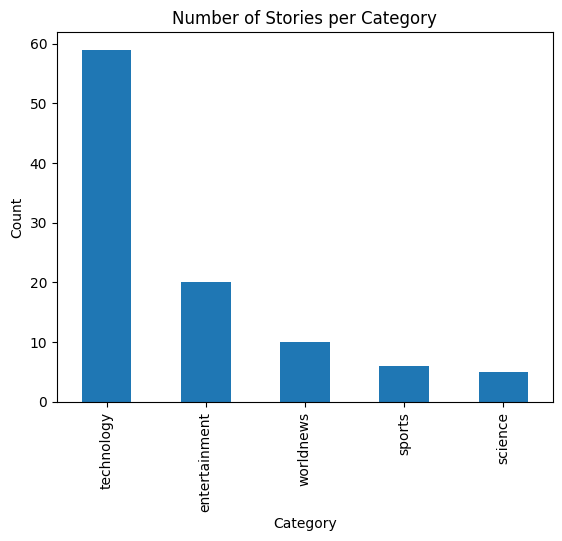

In [28]:
df["category"].value_counts().plot(kind="bar")

plt.title("Number of Stories per Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

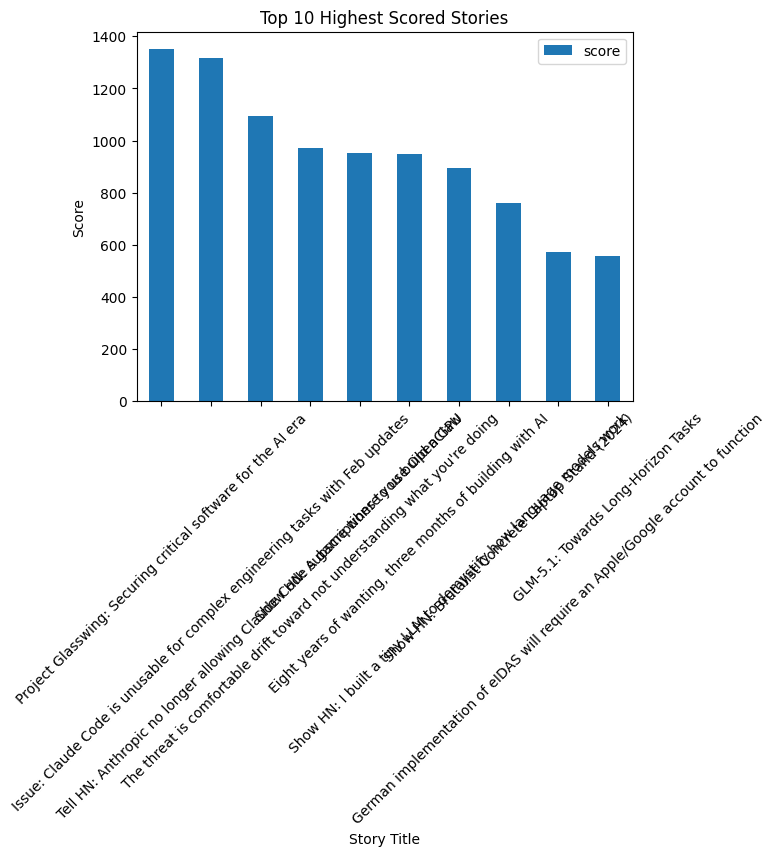

In [27]:
top_scores = df.sort_values(by="score", ascending=False).head(10)

top_scores.plot(x="title", y="score", kind="bar")

plt.title("Top 10 Highest Scored Stories")
plt.xlabel("Story Title")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.show()

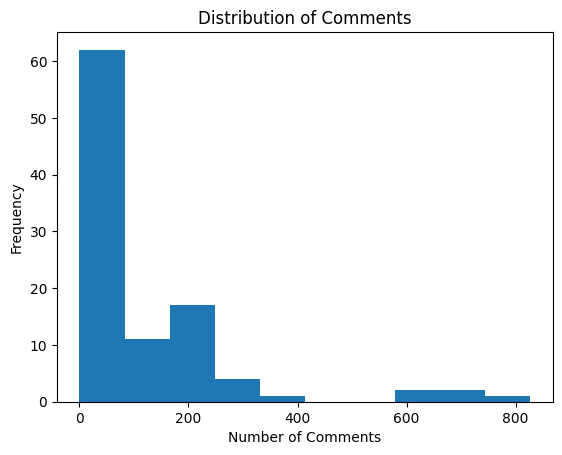

In [30]:
df["num_comments"].plot(kind="hist")

plt.title("Distribution of Comments")
plt.xlabel("Number of Comments")

plt.show()

In [31]:
plt.savefig("graph.png")

<Figure size 640x480 with 0 Axes>